# Problem 1.4

Using an unconstrained optimizer: <br>
Consider the two-dimensional function: <br>

f(x1,x2) = (1 - x1)^2 + (1 - x2)^2 + 1/2 * (2*x2 - x1^2)^2

Plot the contours of this function and find the minimum graphically. Then, use optimization software to find the minimum (see Tip 1.3). Verify that the optimizer converges to the minimum you found graphically. Exploration: (1) Try minimizing the function in Prob. 1.2 starting from different points. (2) Minimize other functions of your choosing. (3) Study the options provided by the optimization software and explore different settings.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

## Approach

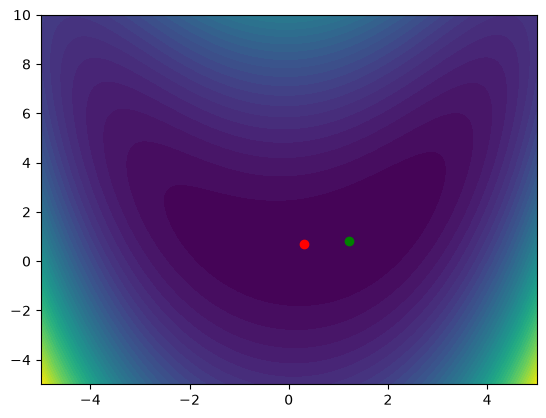

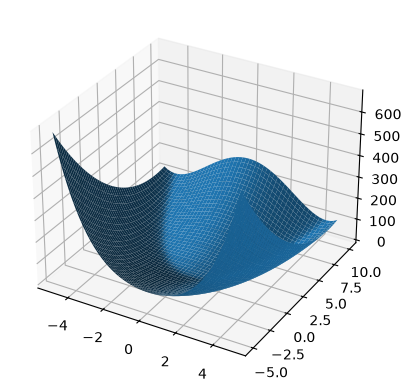

In [35]:
# define the function
def func(x):
    return (1 - x[0])**2 + (1 - x[1])**2 + 0.5*(2*x[1] - x[0]**2)**2

# make data
X1, X2 = np.meshgrid(np.linspace(-5, 5, 500), np.linspace(-5, 10, 500))
Z = func([X1, X2])
levels = np.linspace(np.min(Z), np.max(Z), 45)

# plot
fig1, ax1 = plt.subplots()
ax1.contourf(X1, X2, Z, levels=levels)

ax1.plot(0.3,0.7,'o', color='red') # appriximated minimum
ax1.plot(1.213, 0.824,'o', color='green') # true minimum

fig2, ax2 = plt.subplots(subplot_kw={"projection": "3d"})
ax2.plot_surface(X1, X2, Z, vmin=Z.min())

plt.show()

In [36]:
# find minimum
x0 = np.array([0,0]) # start point
# minimize the function using Nelder-Mead method
result = minimize(func, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})
print(f"Minimum found at: x1 = {result.x[0]:.3f}, x2 = {result.x[1]:.3f} using Nelder-Mead method" )

Optimization terminated successfully.
         Current function value: 0.091944
         Iterations: 97
         Function evaluations: 185
Minimum found at: x1 = 1.213, x2 = 0.824 using Nelder-Mead method


In [37]:
# find minimum
x0 = np.array([0,0]) # start point
# minimize the function using Nelder-Mead method
result = minimize(func, x0, method='BFGS', options={'disp': True})
print(f"Minimum found at: x1 = {result.x[0]:.3f}, x2 = {result.x[1]:.3f} using BFGS method" )

Optimization terminated successfully.
         Current function value: 0.091944
         Iterations: 9
         Function evaluations: 33
         Gradient evaluations: 11
Minimum found at: x1 = 1.213, x2 = 0.824 using BFGS method


In [38]:
# find minimum at different starting point
x0 = np.array([200,200]) # start point
# minimize the function using Nelder-Mead method
result = minimize(func, x0, method='BFGS', options={'disp': True})
print(f"Minimum found at: x1 = {result.x[0]:.3f}, x2 = {result.x[1]:.3f} using BFGS method" )

Optimization terminated successfully.
         Current function value: 0.091944
         Iterations: 27
         Function evaluations: 90
         Gradient evaluations: 30
Minimum found at: x1 = 1.213, x2 = 0.824 using BFGS method


In [39]:
# minimuize different function
def func2(x):
    return x[0]**3 + 2*x[0]*x[1]**2 - x[1]**3 - 20*x[0]

x0 = np.array([1,1]) # start point
result = minimize(func2, x0, method='BFGS', options={'disp': True})
print(f"Minimum found at: x1 = {result.x[0]:.3f}, x2 = {result.x[1]:.3f} using BFGS method" )

Optimization terminated successfully.
         Current function value: -34.426519
         Iterations: 7
         Function evaluations: 30
         Gradient evaluations: 10
Minimum found at: x1 = 2.582, x2 = 0.000 using BFGS method


## Results

(1) optimizer converges to the minimum. my initial guess was incorrect. different staring points sometimes take longer but still converge. interestingly when i start somewhat close to the optimum the optimizer can take longer than if it started slightly further away. it might be that at such flat gradients it "bounces" around more before it settles at the minimum.<br>
(2) i tried the function from problem 1.2. when i start the optimizer close to the local minimum it converges to that (also correction for 1.2 where i said those were saddlepoints, they are a local minium and a local maximum). but if i start slightly further away it does not converge since there is no global minimum. it "falls off the cliff" so to speak.<br>
(3) different settings such as the tolerance define when the optimizer stops. for exampe in very flat gradients it makes sense to decrease the tolerance to get a better result. but if the amount of iterations need to be reduced we can turn up the tolerance to speed up the convergence at the cost of not finding the exact optimum.

## Interpretation

the scipy optimizer is easy to use and there are many ways to try out different things.